# Case 1 - Basics
Welcome to the demonstration notebook where we'll go over all of the Basic functions in the **pylenm** package!<br>
Let’s get started!


# Notebook roadmap

This demo is organized into short sections so you can follow it top-to-bottom.

- Installing, importing, and understanding the package
- Using PyLEnM
- Basic functions

> Tip: In jupyter notebook environment, you can turn on the **Table of Contents** for easier navigation. (View -> Table of Contents)


## Installing, importing, and understanding the package

Make sure to install pylenm from https://pypi.org/project/pylenm/ by running `pip install pylenm` in your environment terminal. Once completed, you should be able to import the package. Note: to update to the latest version of pylenm run: `pip install pylenm --upgrade`

**Note**: To make sure all dependencies (including geospatial libraries such as rasterio and pyproj) are properly installed, it is recommended to first create the environment using the provided [**pylenm_env.yml**](https://github.com/hkzhao7/pylenm/tree/main/pylenm_env.yml) file, then run the demo notebooks in the created environment.

The pylenm_df package has one module: 
   <br>     **PylenmDataFactory:** where all of the package functionality is imported.

Let's import it with other necessary libraries!

In [2]:
# Basic utilities
import pandas as pd
import matplotlib.pyplot as plt

# PyLEnM
import pylenm
from pylenm import PylenmDataFactory

pd.set_option('display.max_rows', 100) # Display a custom number of rows for dataframe

We can verify the package version by typing: `pylenm_df.__version__`

In [3]:
pylenm.__version__

'1.2.3'

# Using PyLEnM

Now let's start exploring the **PylenmDataFactory** module.

First, import our two datasets here. It's located in the same directory in a folder called `data`.<br><br>
pylenm_df takes in two datasets: <br>
1. **Concentration Data:** Dataset containing the concetration values<br>
2. **Construction Data:** Dataset containing the construction information of locations such as the Longitude and Latitude values.

## Load the demo dataset

In [5]:
# --- Option A (default): load demo data locally ---
# If you cloned the repo, the demo data is under: notebooks/data/
url_1 = 'data/farea_data_thru_2015q3_reduced_demo.csv'
url_2 = 'data/farea_station_construction_data.csv'

# # --- Option B: load demo data directly from GitHub (no local repo needed) ---
# # Useful for running notebooks on Google Colab or when you don't have the repo cloned.
# raw_base = "https://raw.githubusercontent.com/hkzhao7/pylenm/main/notebooks/data/"
# url_1 = raw_base + "farea_data_thru_2015q3_reduced_demo.csv"
# url_2 = raw_base + "farea_station_construction_data.csv"

concentration_data = pd.read_csv(url_1)
construction_data = pd.read_csv(url_2)

Now that we have our data imported let's save the data into our functions class.

We do this by initializing **PylenmDataFactory** with our data. We'll call the instance pylenm_df

In [7]:
# Create instance
pylenm_df = PylenmDataFactory(concentration_data) # Save concentration data
pylenm_df.setConstructionData(construction_data) # Save construction data

Successfully imported the data!

Successfully imported the construction data!



If the data passed doesn't meet the package requiremnts, you'll be presented with the following message.

To demonstrate the requirments we'll pass an arbitrary list instead of a dataframe.

In [8]:
PylenmDataFactory([1,2,3,4,5])

ERROR: Make sure the data is a pandas DataFrame.

PYLENM DATA REQUIREMENTS:
The imported data needs to meet ALL of the following conditions to have a successful import:
   1) Data should be a pandas dataframe.
   2) Data must have these column names: 
      ['COLLECTION_DATE','STATION_ID','ANALYTE_NAME','RESULT','RESULT_UNITS']


## Quick data check

We can view the concentration data we imported by running the `getData()` function.

In [12]:
pylenm_df.getData().head()

,ID,FACILITY,FFA_INDEX_NO,SRS_AREA,OPERABLE_UNIT,STATION_ID,STATION_TYPE,SEIR_ID,STATION_USE,REVISION_ID,...,RESULT_UNITS,COUNTING_UNCERTAINTY,MATRIX_CODE,VALIDATION_STATUS,FIELD_QC_CODE,LAB_QC_CODE,LAB_CODE,ANALYTE_TYPE,DILUTION_FACTOR,SAMPLER_COMMENTS
0,767202,SRS,19,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FOB-015D,MONITORING WELL,NaN,F_PLUME_ASSESS; H_AUX;MW_AUX,NaN,...,ft,NaN,NaN,UE,NaN,NaN,NaN,NaN,NaN,PROG_NAME=W
1,767203,SRS,19,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FSB-133D,MONITORING WELL,NaN,F_PLUME_ASSESS; H_AUX;MW_AUX,NaN,...,ft,NaN,NaN,UE,NaN,NaN,NaN,NaN,NaN,PROG_NAME=W
2,767204,SRS,19,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FSB-134D,MONITORING WELL,NaN,F_PLUME_ASSESS; H_AUX;MW_AUX,NaN,...,ft,NaN,NaN,UE,NaN,NaN,NaN,NaN,NaN,PROG_NAME=W
3,767205,SRS,19,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FSB-136D,MONITORING WELL,NaN,F_PLUME_ASSESS; H_AUX;MW_AUX,NaN,...,ft,NaN,NaN,UE,NaN,NaN,NaN,NaN,NaN,PROG_NAME=W
4,767206,SRS,19,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FSB-122D,MONITORING WELL,NaN,F_PLUME;H_AUX;MW_AUX,NaN,...,ft,NaN,NaN,UE,NaN,NaN,NaN,NaN,NaN,PROG_NAME=W


The same can be done for the construction data by running the `get_Construction_Data()` function.

In [14]:
pylenm_df.get_Construction_Data().head()

,FACILITY_ID,SITE_GROUP,SITE_NAME,STATION_TYPE,STATION USE,AQUIFER,STATION_USE,LATITUDE,LONGITUDE,EASTING,...,SZ_BOT(FT MSL),GROUND_ELEVATION,REFERENCE_ELEVATION_CODE,REFERENCE_ELEVATION,TOTAL_DEPTH,CONSTR_OBJ_DIAMETER,CONSTR_OBJ_MATERIAL,PUMP_TYPE,COMPLETION_DATE,DATE_SEALED
STATION_ID,,,,,,,,,,,,,,,,,,,,,
FAI-001A,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273872,-81.622904,441989.564,...,231.30,250.1,C,252.63,19.10,2.0,PVC,NONE,3/22/2016,NaN
FAI-001B,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273873,-81.622891,441990.781,...,240.60,250.2,C,252.73,9.90,2.0,PVC,NONE,3/22/2016,NaN
FAI-001C,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273874,-81.622895,441990.432,...,242.68,250.2,C,252.74,7.82,2.0,PVC,NONE,3/22/2016,NaN
FAI-001D,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273874,-81.622901,441989.928,...,246.75,250.1,C,252.56,3.65,2.0,PVC,NONE,3/22/2016,NaN
FAI-002A,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.263961,-81.685462,436156.287,...,165.88,185.1,C,187.58,3.65,2.0,PVC,NONE,3/29/2016,NaN


At any point we can also reset the current working dataset by running `setData()` for the concentration data and `setConstructionData()` for the construction data.

In [15]:
pylenm_df.setData(concentration_data)
pylenm_df.setConstructionData(construction_data)

Successfully imported the data!

Successfully imported the construction data!



We'll set the `inplace` parameter to `True` to make it the default working dataset. 

In [16]:
pylenm_df.simplify_data(inplace=True).head()

,COLLECTION_DATE,STATION_ID,ANALYTE_NAME,RESULT,RESULT_UNITS
0,1990-01-01,FSB-077,PH,3.30,pH
1,1990-01-01,FSB-105C,DEPTH_TO_WATER,80.49,ft
2,1990-01-01,FSB-107D,SPECIFIC CONDUCTANCE,289.00,uS/cm
3,1990-01-01,FSB-101A,DEPTH_TO_WATER,134.49,ft
4,1990-01-01,FSB-101A,SPECIFIC CONDUCTANCE,161.00,uS/cm


# Basic functions

## Filtering and summary functions

Let's generate some useful reports about the data by calling `get_analyte_details` and `get_data_summary`

### get_analyte_details()

`get_analyte_details` tells you the temporal coverage and the number of unique samples for a specific analyte by station (well).

In [38]:
pylenm_df.get_analyte_details(analyte_name='DEPTH_TO_WATER').head()

,Start Date,End Date,Date Range (days),Unique samples
Station Name,,,,
FSB-094D,1990-01-01,1990-10-08,280,4
FSB-095D,1990-01-01,1990-10-08,280,4
FSB-077,1990-01-01,2006-10-16,6132,122
FSB-111C,1990-01-01,2006-10-17,6133,115
FSB-105C,1990-01-01,2006-10-19,6135,127


Most functions have a filtering feature which uses the `filter_by_column` fucntion to reduced the search space.<br>
We'll run `get_analyte_details` again but this time we'll view the results for the 'Lower Aquifer' stations only.

In [39]:
pylenm_df.get_analyte_details('TRITIUM', filter=True, col='AQUIFER', equals=['LAZ_UTRAU']).head()

,Start Date,End Date,Date Range (days),Unique samples
Station Name,,,,
FSB-093C,1990-01-01,2015-07-28,9339,103
FSB-107C,1990-01-01,2015-08-04,9346,103
FSB-094C,1990-01-02,2015-07-28,9338,109
FSB-097C,1990-01-03,2015-07-29,9338,103
FSB-098C,1990-01-03,2015-07-29,9338,102


### get_data_summary()

`get_data_summary` is another useful function that summarizes information by analyte, including temporal coverage, number of unique stations (stations), samples, and measurement unitm etc.

In [40]:
pylenm_df.get_data_summary(analytes=['TRITIUM','IODINE-129','SPECIFIC CONDUCTANCE',
                                     'PH','URANIUM-238', 'DEPTH_TO_WATER'], sort_by='stations').head()

,Start Date,End Date,Date Range (days),# unique stations,# samples,Unit,mean,std,min,25%,50%,75%,max
Analyte Name,,,,,,,,,,,,,
TRITIUM,1990-01-01,2015-09-23,9396 days,160,13476,pCi/mL,1248.316406,3261.565925,-0.628,25.300,193.00,934.0,44800.0
PH,1990-01-01,2015-09-23,9396 days,158,18517,pH,5.354886,1.529332,0.000,4.100,5.20,6.4,12.7
SPECIFIC CONDUCTANCE,1990-01-01,2015-09-23,9396 days,156,18276,uS/cm,425.754861,555.068915,0.000,87.000,213.00,544.0,10700.0
DEPTH_TO_WATER,1990-01-01,2015-09-24,9397 days,155,20091,ft,46.814224,38.137888,0.500,16.450,32.17,72.9,177.2
IODINE-129,1990-01-06,2015-09-23,9391 days,150,5405,pCi/L,41.624339,92.511351,-356.900,0.996,9.37,45.1,1620.0


Here is the same function but with the same filtering we applied above ('Lower Aquifer' stations).

In [41]:
pylenm_df.get_data_summary(analytes=['TRITIUM','IODINE-129','SPECIFIC CONDUCTANCE',
                                     'PH','URANIUM-238', 'DEPTH_TO_WATER'],
                                     filter=True, col='AQUIFER', equals=['LAZ_UTRAU'], sort_by='stations').head()

,Start Date,End Date,Date Range (days),# unique stations,# samples,Unit,mean,std,min,25%,50%,75%,max
Analyte Name,,,,,,,,,,,,,
TRITIUM,1990-01-01,2015-08-10,9352 days,29,2961,pCi/mL,1904.185517,3350.574654,-0.387,69.700,638.00,1630.000,40000.00
SPECIFIC CONDUCTANCE,1990-01-01,2015-08-10,9352 days,29,4350,uS/cm,547.272770,668.286641,0.000,72.000,300.00,660.000,10600.00
DEPTH_TO_WATER,1990-01-01,2015-09-24,9397 days,29,4138,ft,54.328794,25.240702,4.750,25.515,67.45,75.680,120.13
PH,1990-01-01,2015-08-10,9352 days,29,4402,pH,5.208301,1.135237,0.000,4.400,5.30,5.830,12.60
IODINE-129,1990-01-06,2015-08-10,9347 days,27,1246,pCi/L,29.382026,40.177638,-16.150,2.000,11.00,36.075,233.00


### filter_by_column()

You can use `filter_by_column` to check the station construction information for 'Lower Aquifer' station as below.

In [22]:
pylenm_df.filter_by_column(construction_data, col='AQUIFER', equals=['LAZ_UTRAU']).head()

,FACILITY_ID,SITE_GROUP,SITE_NAME,STATION_ID,STATION_TYPE,STATION USE,AQUIFER,STATION_USE,LATITUDE,LONGITUDE,...,SZ_BOT(FT MSL),GROUND_ELEVATION,REFERENCE_ELEVATION_CODE,REFERENCE_ELEVATION,TOTAL_DEPTH,CONSTR_OBJ_DIAMETER,CONSTR_OBJ_MATERIAL,PUMP_TYPE,COMPLETION_DATE,DATE_SEALED
44,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FBI-014C,MONITORING WELL,Auxiliary Observation,LAZ_UTRAU,ACTIVE,33.271667,-81.677454,...,148.78,222.80,S,225.58,76.52,2.0,PVC,VARIABLE SPEED PUMP,12/30/2003,NaN
47,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FBI-016C,MONITORING WELL,Auxiliary Observation,LAZ_UTRAU,ACTIVE,33.271394,-81.678173,...,145.00,225.00,S,227.92,81.60,2.0,PVC,VARIABLE SPEED PUMP,12/19/2003,NaN
144,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FOB-002C,MONITORING WELL,Auxiliary Observation,LAZ_UTRAU,ACTIVE,33.270220,-81.680036,...,146.56,226.58,S,229.57,82.52,2.0,PVC,VARIABLE SPEED PUMP,12/31/2003,NaN
148,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FOB-005C,MONITORING WELL,Auxiliary Observation,LAZ_UTRAU,ACTIVE,33.271922,-81.680770,...,129.32,256.34,C,258.84,132.00,2.0,PVC,NaN,10/11/1996,NaN
150,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,FOB-007C,MONITORING WELL,Auxiliary Observation,LAZ_UTRAU,ACTIVE,33.275991,-81.682290,...,148.87,295.85,C,298.35,152.00,2.0,PVC,NaN,10/8/1996,NaN


### get_station_analytes()

You can use `get_station_analytes` to see what analytes are sampled at a specific station.

In [42]:
pylenm_df.get_station_analytes(station_name='FSB-102C')

FSB-102C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']



You can also use it to see what analytes are sampled at more locations (stations), for example, at those 'Lower Aquifer' stations.

In [43]:
pylenm_df.get_station_analytes(filter=True, col='AQUIFER', equals=['LAZ_UTRAU'])

FSB-107C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-093C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-094C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-097C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-098C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-102C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-087C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-090C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTIUM-90', 'TRITIUM', 'URANIUM-238']

FSB-078C
['DEPTH_TO_WATER', 'IODINE-129', 'PH', 'SPECIFIC CONDUCTANCE', 'STRONTI

## Check the temporal coverage of the data

### plot_all_time_series_simple()

`plot_all_time_series_simple` is a function that visualizes the temporal data coverage of all stations.

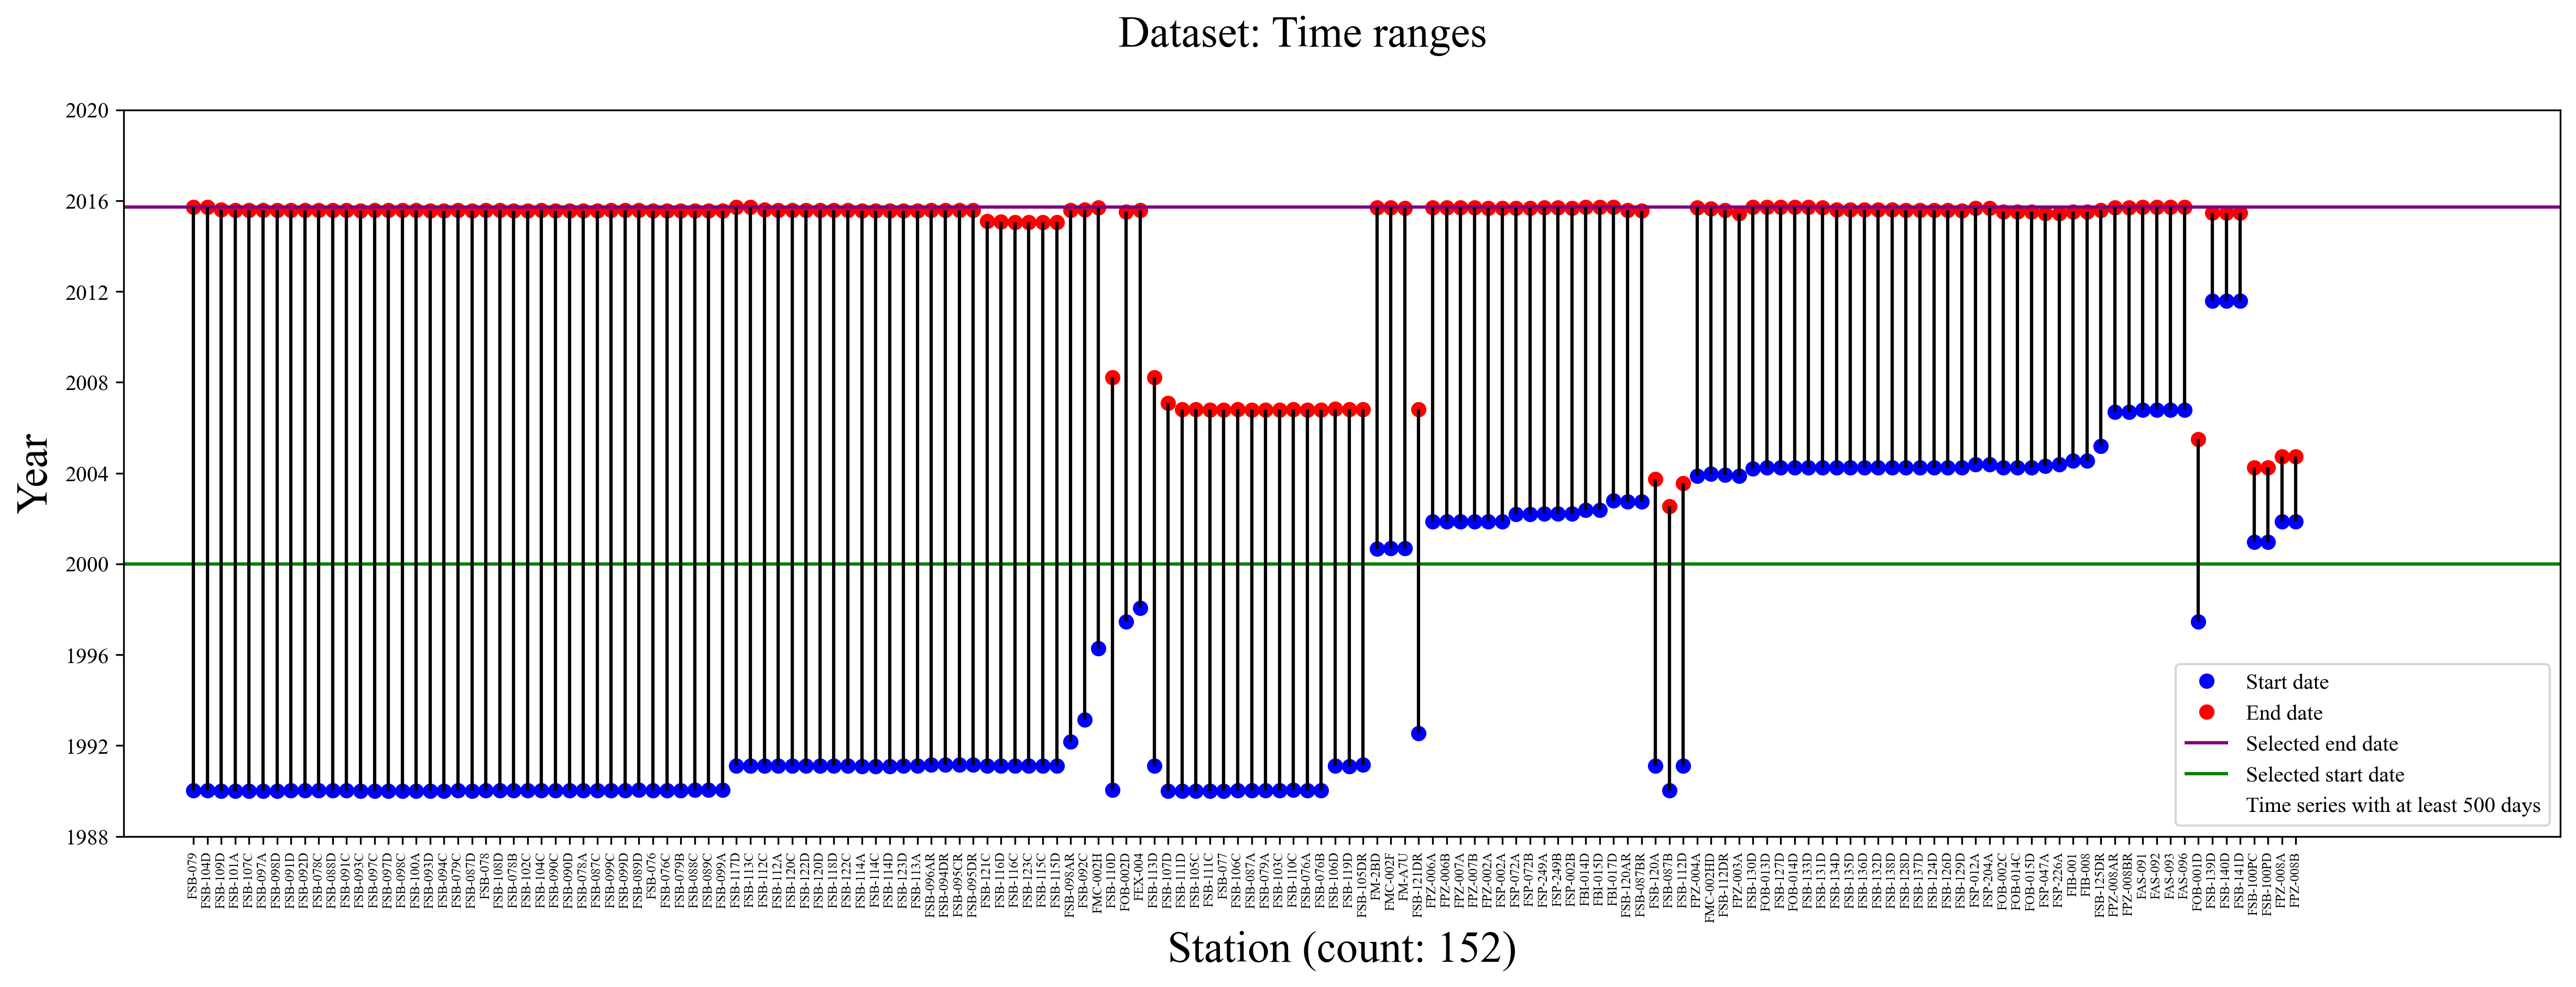

In [44]:
pylenm_df.plot_all_time_series_simple(start_date='2000-1-1', min_days=500)

You can also use it to check the temporal data coverage for a specific analyte.

,STATION_ID,START_DATE,END_DATE,RANGE
0,FSB-091D,1990-01-06,2015-08-03,9340 days
1,FSB-092D,1990-01-06,2015-08-03,9340 days
2,FSB-078C,1990-01-07,2015-08-03,9339 days
3,FSB-079,1990-01-09,2015-08-03,9337 days
4,FSB-079C,1990-01-09,2015-08-03,9337 days


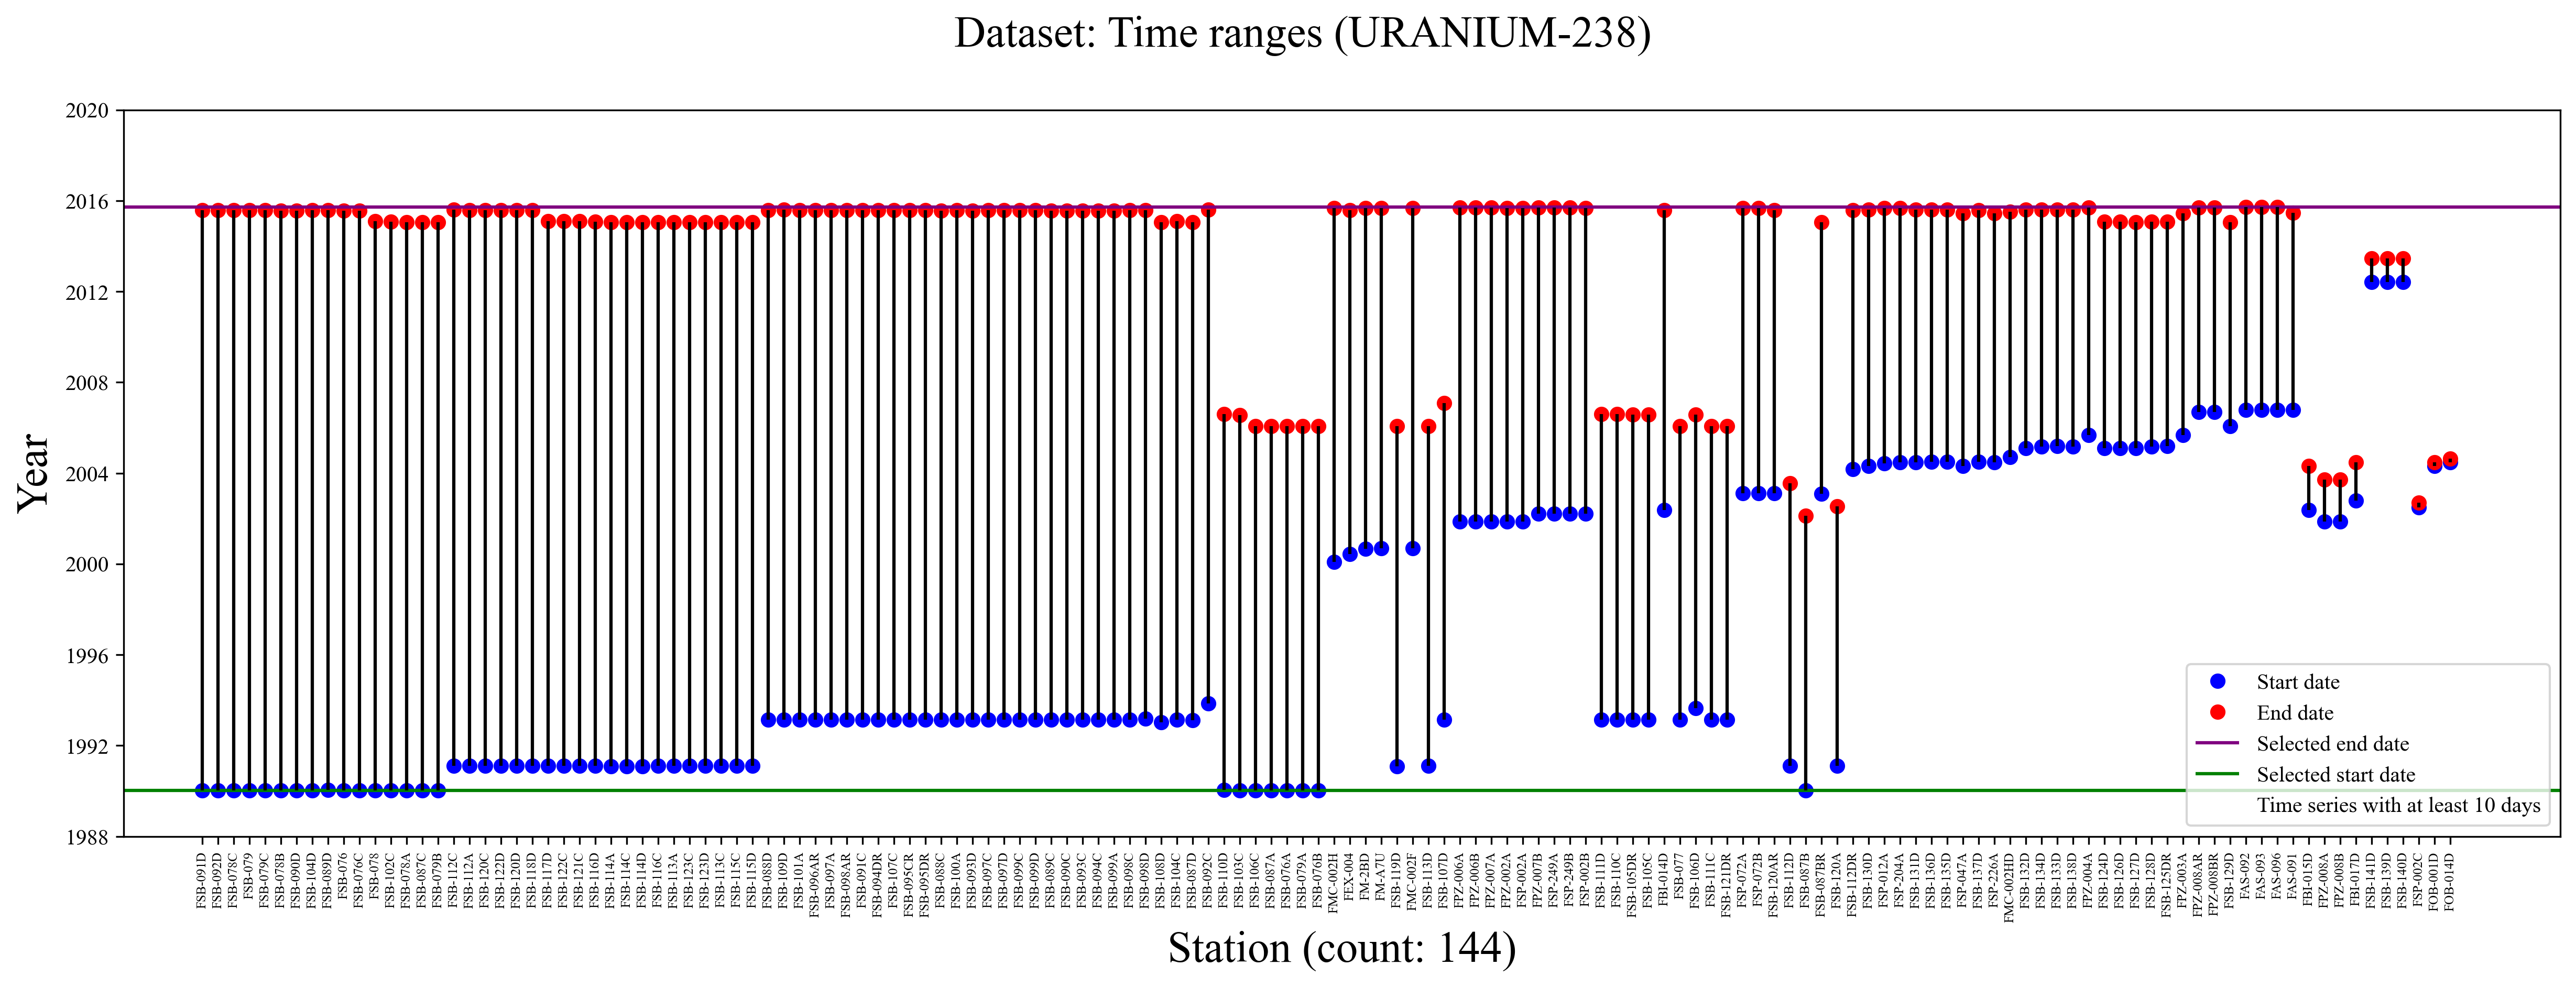

In [31]:
ur = pylenm_df.plot_all_time_series_simple(analyte_name='URANIUM-238', x_max_lim=150, return_data=True).head()
ur

It is flexible with several parameters that you can use to further filter the results.

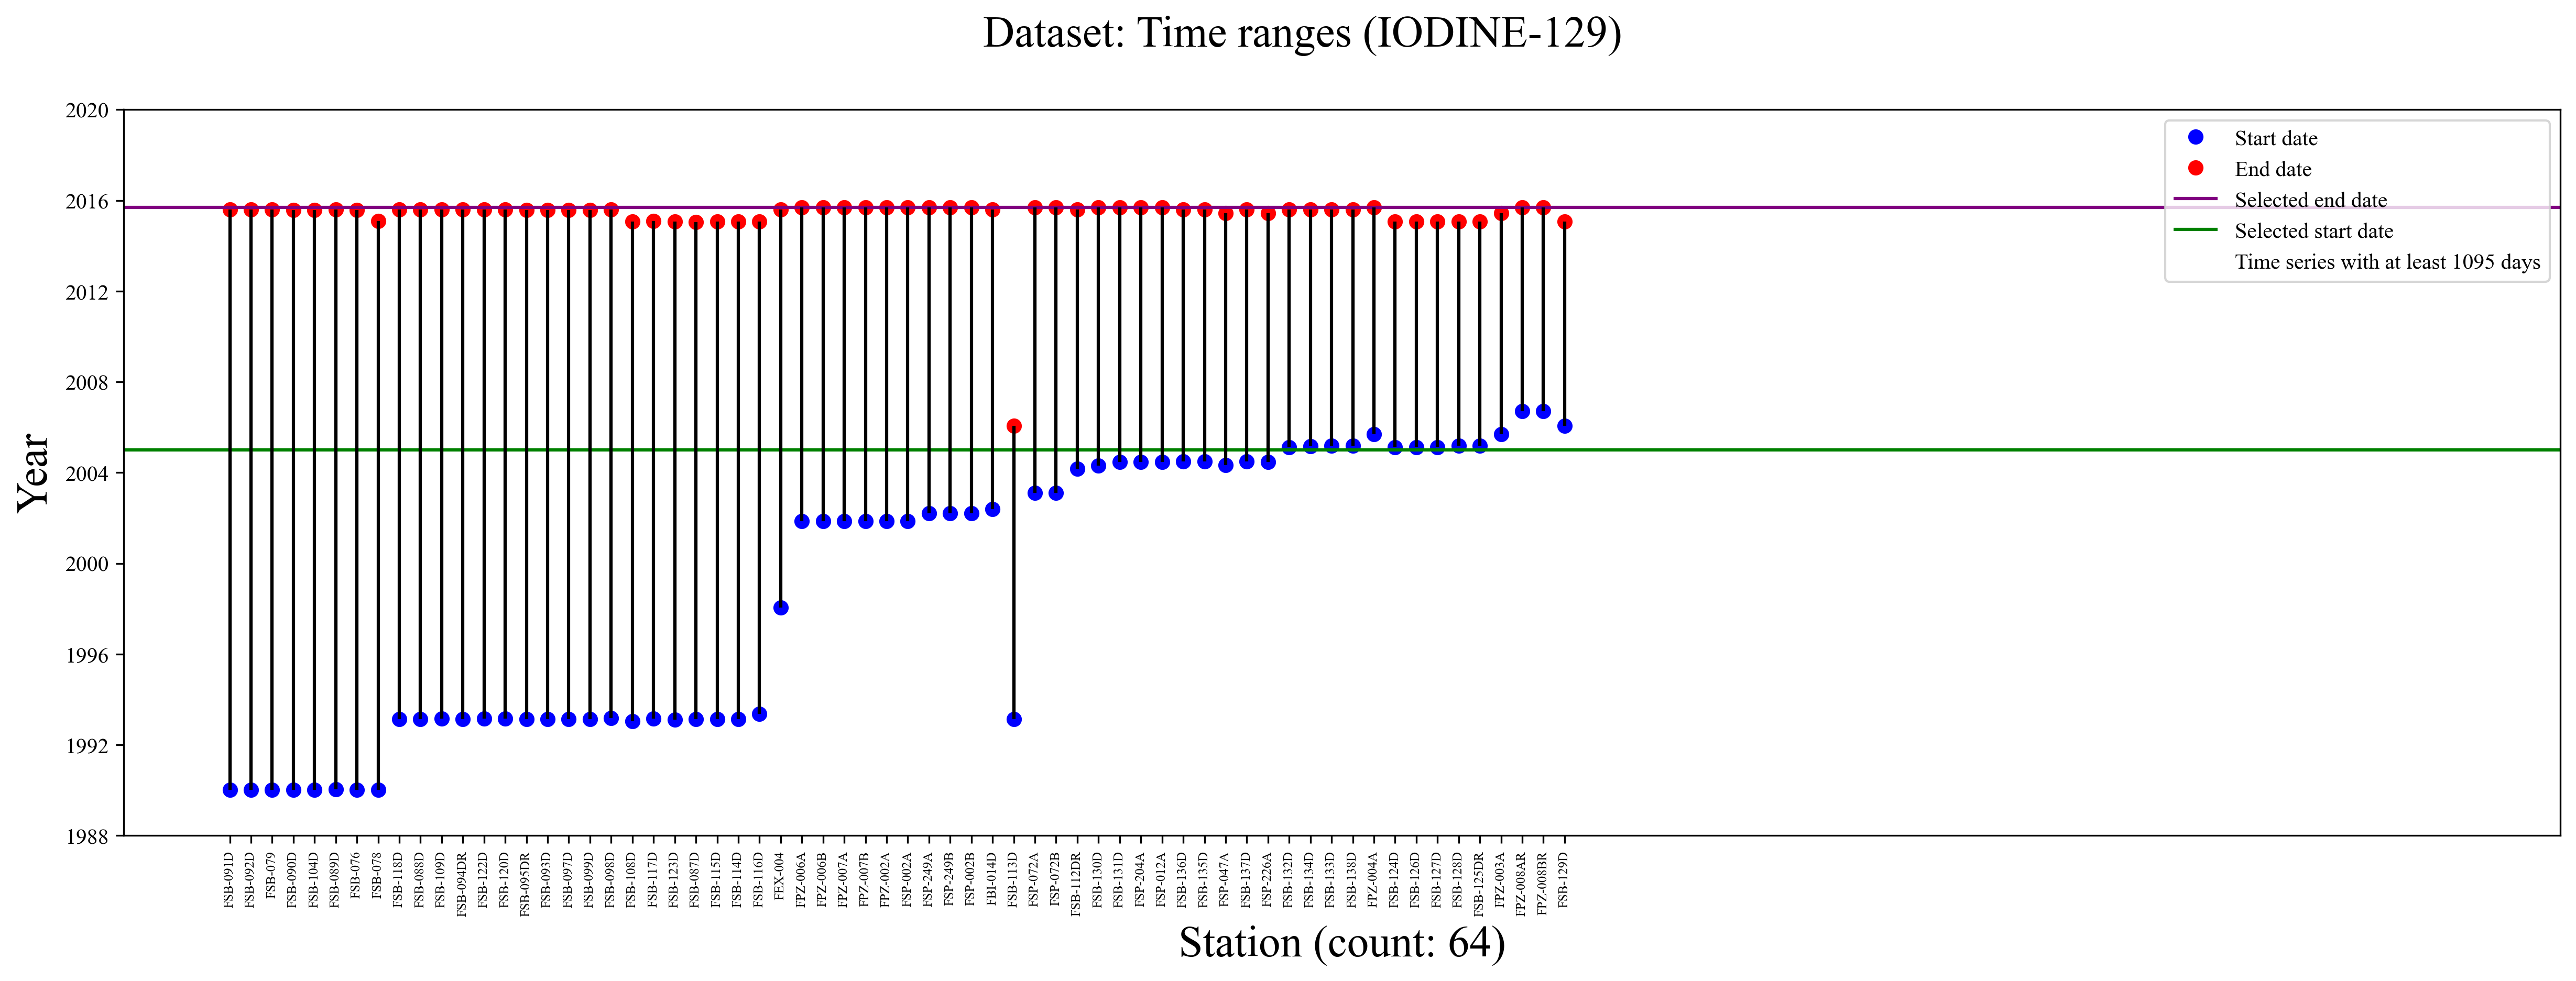

In [45]:
# Added filtering of 'Upper Aquifer' stations
pylenm_df.plot_all_time_series_simple(analyte_name='IODINE-129', min_days=3*365, x_max_lim=110, filter=True, col='AQUIFER', equals=['UAZ_UTRAU'], start_date='2005-1-1')

### plot_all_time_series()

`plot_all_time_series` goes one step further by visualizing the actual measurement data along the time axis at each station.

For examlpe, the implementation below shows the DEPTH_TO_WATER measurements by station, the color bar on the right side explains the measurement range and value.

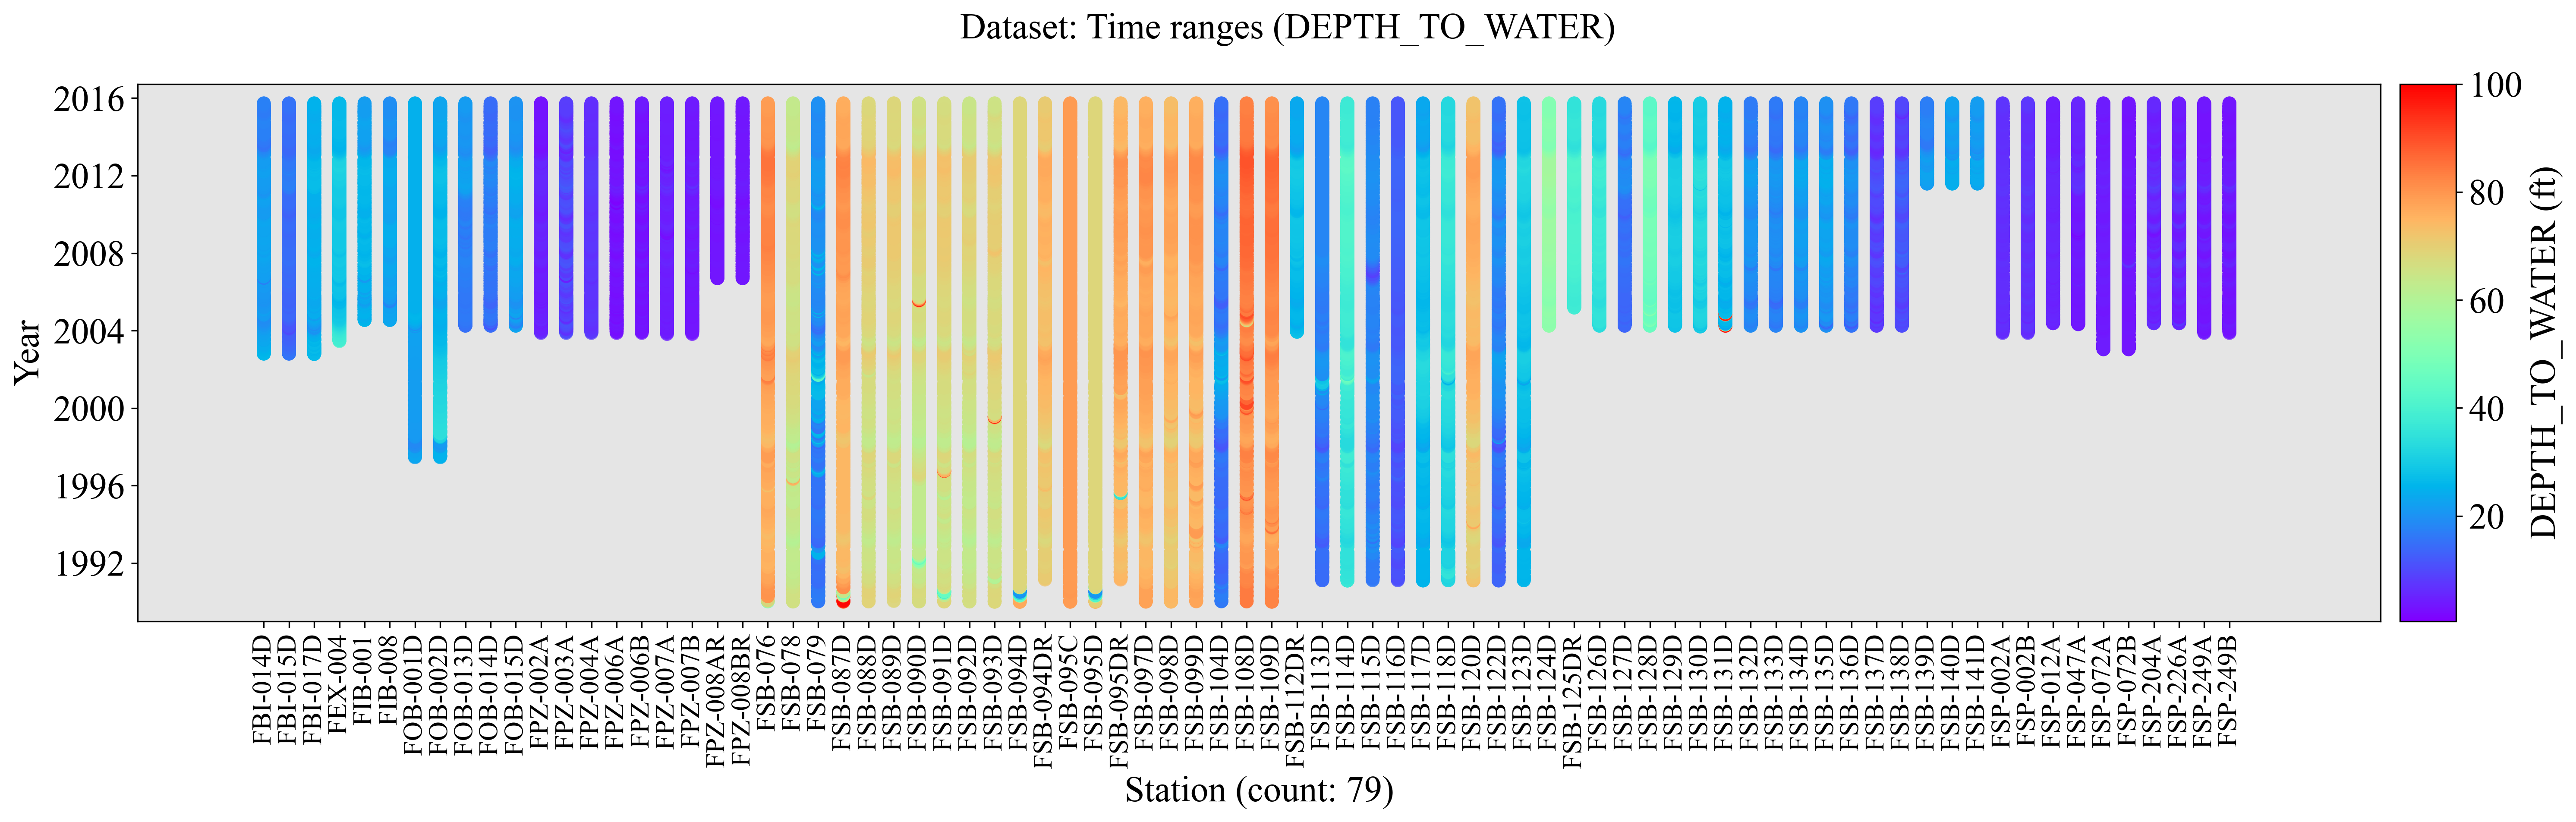

In [33]:
WT_UA = pylenm_df.plot_all_time_series(analyte_name='DEPTH_TO_WATER', filter=True, col='AQUIFER', equals=['UAZ_UTRAU'], 
                                       x_label_size=15, marker_size=60, return_data=True, cbar_max=100, y_2nd_label='DEPTH_TO_WATER (ft)')

Here is another exmaple showing the log-transformed TRITIUM concentration measurements by station.

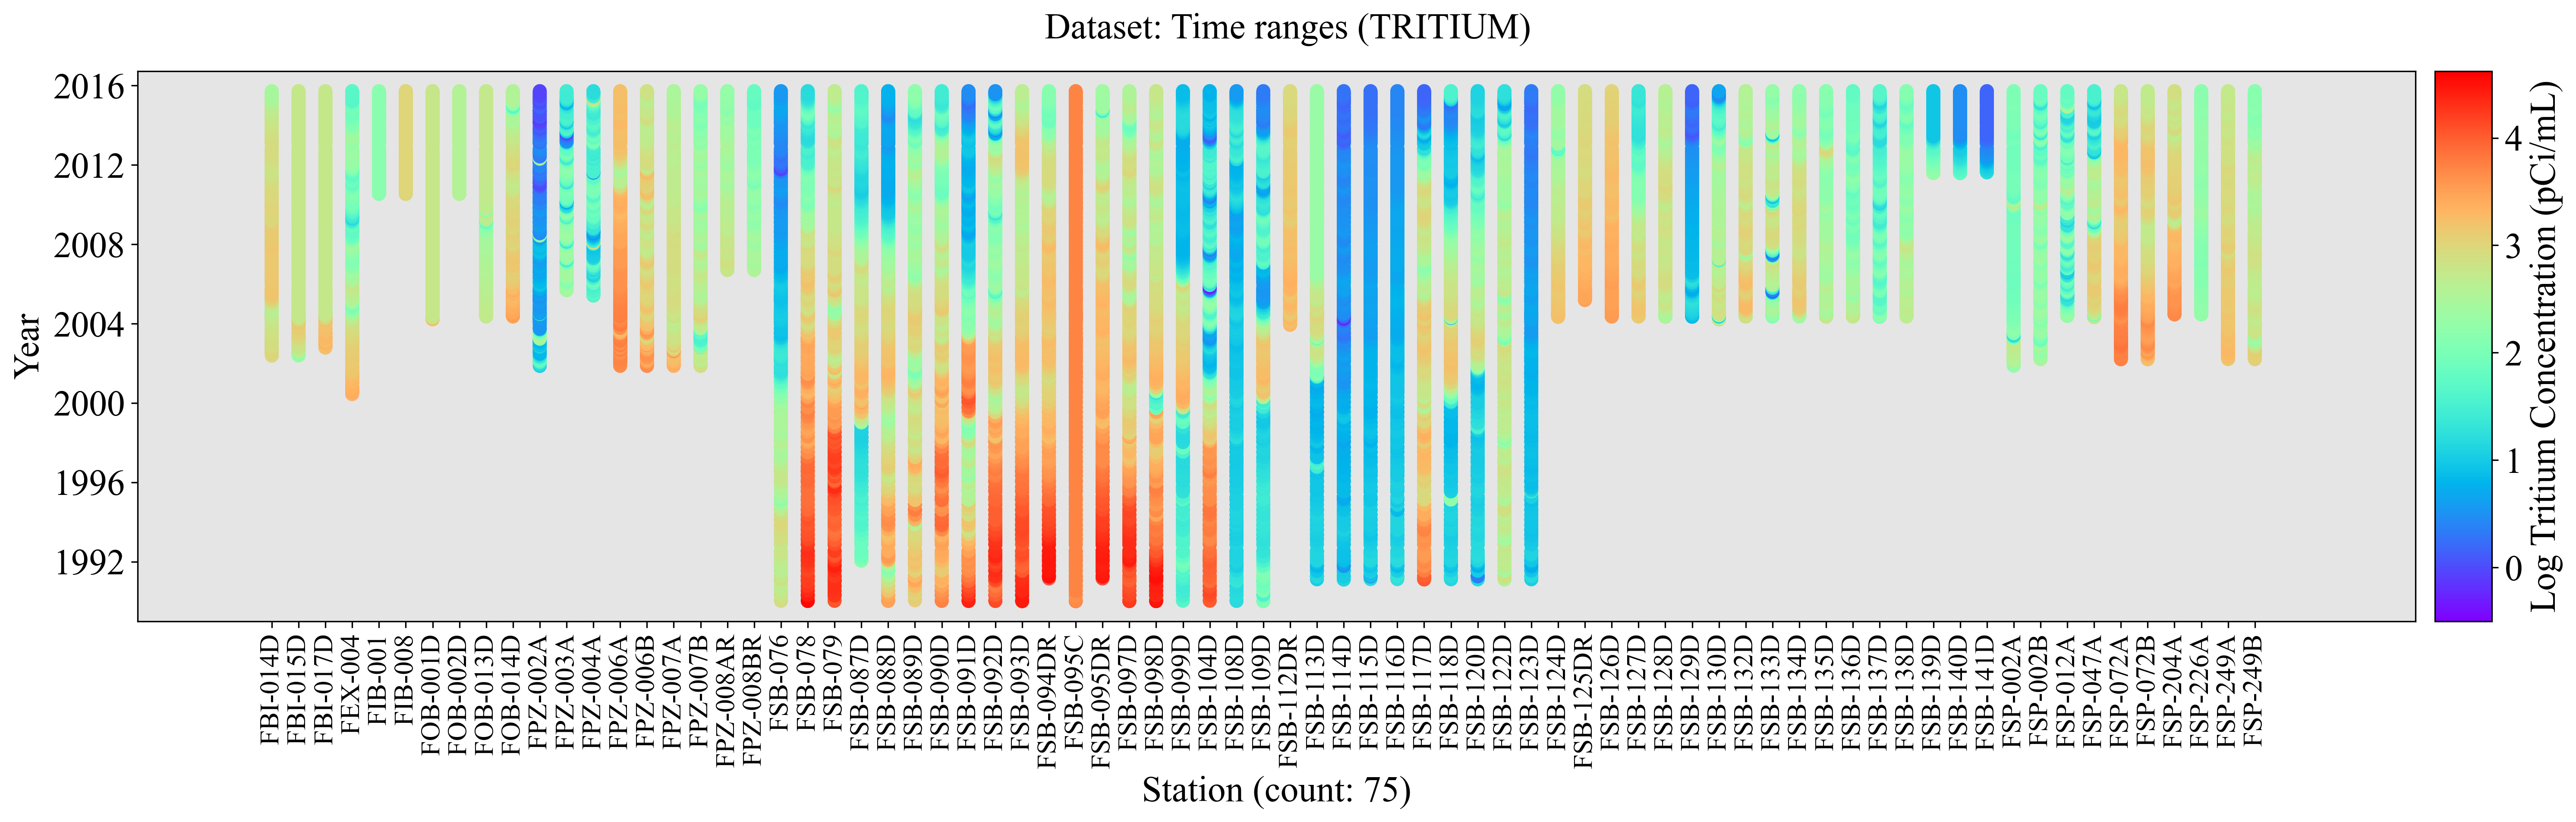

In [34]:
TR_UP = pylenm_df.plot_all_time_series(analyte_name='TRITIUM', filter=True, col='AQUIFER', equals=['UAZ_UTRAU'], 
                                       x_label_size=15, marker_size=60, log_transform=True, return_data=True, drop_cols=['FSB-131D'],
                                       cbar_min=-0.5, y_2nd_label='Log Tritium Concentration (pCi/mL)')

## Interpolate data

### interpolate_stations_by_analyte()

The `interpolate_stations_by_analyte` function interpolates and combines all of the stations with the same analyte. There is no need to specify a start and end date as the algorithm will find the optimum start and end date.

When using the interpolation functionality, a resampling frequency should be specifed. Allowed frequency formats can be found in the function description. 

The example below shows how to interpolate DEPTH_TO_WATER measurements for all stations into **daily** frequency.

In [46]:
wt = pylenm_df.interpolate_stations_by_analyte(analyte='DEPTH_TO_WATER',
                                            frequency='D',
                                            rm_outliers=True,
                                            z_threshold=2.5)
wt.head()

,FBI-014D,FBI-015D,FBI-017D,FEX-004,FIB-001,FIB-008,FOB-001D,FOB-002C,FOB-002D,FOB-013D,...,FSP-002A,FSP-002B,FSP-012A,FSP-047A,FSP-072A,FSP-072B,FSP-204A,FSP-226A,FSP-249A,FSP-249B
1990-01-01,21.099175,14.477747,24.741716,29.169679,24.858877,22.308405,23.60062,29.637708,26.672342,18.594071,...,6.537683,6.753825,5.172009,4.508485,4.213795,3.435826,5.388981,5.039743,3.897663,3.598162
1990-01-02,21.099175,14.477747,24.741716,29.169679,24.858877,22.308405,23.60062,29.637708,26.672342,18.594071,...,6.537683,6.753825,5.172009,4.508485,4.213795,3.435826,5.388981,5.039743,3.897663,3.598162
1990-01-03,21.099175,14.477747,24.741716,29.169679,24.858877,22.308405,23.60062,29.637708,26.672342,18.594071,...,6.537683,6.753825,5.172009,4.508485,4.213795,3.435826,5.388981,5.039743,3.897663,3.598162
1990-01-04,21.099175,14.477747,24.741716,29.169679,24.858877,22.308405,23.60062,29.637708,26.672342,18.594071,...,6.537683,6.753825,5.172009,4.508485,4.213795,3.435826,5.388981,5.039743,3.897663,3.598162
1990-01-05,21.099175,14.477747,24.741716,29.169679,24.858877,22.308405,23.60062,29.637708,26.672342,18.594071,...,6.537683,6.753825,5.172009,4.508485,4.213795,3.435826,5.388981,5.039743,3.897663,3.598162


### interpolate_station_data()

`interpolate_station_data` is a light-weight function that focuses for single stations -- only one station name should be specified for the function.

In [47]:
pylenm_df.interpolate_station_data(station_name='FSB-095DR',
                                analytes=['DEPTH_TO_WATER', 'URANIUM-238'],
                                frequency='2M').head()

,DEPTH_TO_WATER,URANIUM-238
COLLECTION_DATE,,
1993-02-28,73.030,1620.0
1993-04-30,72.120,1475.0
1993-06-30,71.325,1330.0
1993-08-31,71.940,1100.0
1993-10-31,72.540,1155.0
